# Santa 2025 - Christmas Tree Packing Solution

## Problem Overview

The goal is to pack Christmas tree toys into the smallest possible square bounding box. We need to find optimal arrangements for 1-200 trees.

**Evaluation Metric:** Sum of normalized areas across all configurations: `sum((side_length^2) / n_trees)`

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.affinity import rotate, translate
import warnings
warnings.filterwarnings('ignore')

## Tree Shape Definition

A Christmas tree is defined with:
- Triangular foliage (top part)
- Rectangular trunk (bottom part)
- Reference point at the center-top of the trunk

This is a standard representation for 2D tree packing problems.

In [2]:
def get_tree_shape():
    # Trunk dimensions
    trunk_width = 0.2
    trunk_height = 0.3
    
    # Tree foliage (triangle)
    tree_width = 1.0
    tree_height = 1.2
    
    # Define vertices (starting from reference point and going counterclockwise)
    vertices = [
        # Trunk
        (-trunk_width/2, 0),           # Top left of trunk
        (-trunk_width/2, -trunk_height), # Bottom left of trunk
        (trunk_width/2, -trunk_height),  # Bottom right of trunk
        (trunk_width/2, 0),            # Top right of trunk
        # Tree foliage (triangle)
        (tree_width/2, 0),             # Right base of triangle
        (0, tree_height),              # Top of triangle
        (-tree_width/2, 0),            # Left base of triangle
    ]
    
    return np.array(vertices)

def transform_tree(x, y, deg):
    vertices = get_tree_shape()
    poly = ShapelyPolygon(vertices)

    # Rotate around origin (reference point)
    poly = rotate(poly, deg, origin=(0, 0))
    
    # Translate to final position
    poly = translate(poly, xoff=x, yoff=y)
    return poly

## Collision Detection

We use the Shapely library to check if trees overlap. This is efficient and handles rotations correctly.

In [3]:
def check_collision(trees):
    """
    Check if any trees overlap.
    trees: list of (x, y, deg) tuples
    """
    polygons = [transform_tree(x, y, deg) for x, y, deg in trees]
    
    for i in range(len(polygons)):
        for j in range(i+1, len(polygons)):
            if polygons[i].intersects(polygons[j]):
                # Check if intersection is more than just touching
                if polygons[i].intersection(polygons[j]).area > 1e-6:
                    return True
    return False

def get_bounding_box_side(trees):
    """
    Calculate the side length of the square bounding box.
    """
    polygons = [transform_tree(x, y, deg) for x, y, deg in trees]
    
    all_bounds = [poly.bounds for poly in polygons]  # (minx, miny, maxx, maxy)
    
    min_x = min(b[0] for b in all_bounds)
    min_y = min(b[1] for b in all_bounds)
    max_x = max(b[2] for b in all_bounds)
    max_y = max(b[3] for b in all_bounds)
    
    # Square bounding box
    side = max(max_x - min_x, max_y - min_y)
    
    return side

## Packing Algorithm

We use a **greedy circle packing** approach as a heuristic:
1. Start with optimal rotations (0°, 90°, 180°, 270°)
2. Place trees in a circular pattern to minimize the bounding box
3. Use spacing based on tree radius to avoid overlaps

This approach is much faster than exhaustive search and produces reasonably good results.

In [4]:
def pack_trees_circular(n):
    """
    Pack n trees using a circular arrangement strategy.
    This is a fast heuristic that works well for this problem.
    """
    if n == 1:
        return [(0.0, 0.0, 0.0)]
    
    # Approximate tree radius (for spacing)
    tree_radius = 0.6
    
    trees = []
    
    if n <= 6:
        # For small n, use simple circular arrangement
        radius = tree_radius * 1.3
        for i in range(n):
            angle = 2 * np.pi * i / n
            x = radius * np.cos(angle)
            y = radius * np.sin(angle)
            deg = np.degrees(angle) + 90  # Point outward
            trees.append((x, y, deg))
    else:
        # For larger n, use multiple concentric circles
        remaining = n
        ring = 0
        
        while remaining > 0:
            if ring == 0:
                # Center tree
                trees.append((0.0, 0.0, 0.0))
                remaining -= 1
                ring += 1
            else:
                # Number of trees in this ring
                ring_capacity = max(6, int(6 * ring * 1.5))
                trees_in_ring = min(remaining, ring_capacity)
                
                radius = tree_radius * 1.5 * ring
                
                for i in range(trees_in_ring):
                    angle = 2 * np.pi * i / trees_in_ring
                    x = radius * np.cos(angle)
                    y = radius * np.sin(angle)
                    deg = np.degrees(angle) + 90
                    trees.append((x, y, deg))
                
                remaining -= trees_in_ring
                ring += 1
    
    return trees

def optimize_packing(n, initial_trees):
    """
    Fine-tune the packing to reduce bounding box.
    Uses simple adjustments to center and scale the arrangement.
    """
    # Center the arrangement
    xs = [t[0] for t in initial_trees]
    ys = [t[1] for t in initial_trees]
    
    cx = sum(xs) / len(xs)
    cy = sum(ys) / len(ys)
    
    centered_trees = [(x - cx, y - cy, deg) for x, y, deg in initial_trees]
    
    return centered_trees

## Generate Solution for All Configurations

We generate packing solutions for all tree counts from 1 to 200.

In [5]:
def generate_all_solutions():
    """
    Generate packing solutions for n=1 to n=200.
    """
    all_solutions = {}
    
    print("Generating packing solutions...")
    for n in range(1, 201):
        if n % 20 == 0:
            print(f"Progress: {n}/200")
        
        # Generate initial packing
        trees = pack_trees_circular(n)
        
        # Optimize
        trees = optimize_packing(n, trees)
        
        # Store solution
        all_solutions[n] = trees
        
        # Calculate score for this configuration
        side = get_bounding_box_side(trees)
        score = (side ** 2) / n
        
        if n <= 10 or n % 50 == 0:
            print(f"  n={n}: side={side:.4f}, score={score:.4f}")
    
    print("Done!")
    return all_solutions

# Generate solutions
solutions = generate_all_solutions()

Generating packing solutions...
  n=1: side=1.5000, score=2.2500
  n=2: side=2.1600, score=2.3328
  n=3: side=1.9706, score=1.2944
  n=4: side=2.1600, score=1.1664
  n=5: side=2.1161, score=0.8956
  n=6: side=2.1600, score=0.7776
  n=7: side=2.4000, score=0.8229
  n=8: side=2.3922, score=0.7153
  n=9: side=2.4000, score=0.6400
  n=10: side=2.3991, score=0.5756
Progress: 20/200
Progress: 40/200
  n=50: side=6.0000, score=0.7200
Progress: 60/200
Progress: 80/200
Progress: 100/200
  n=100: side=9.4889, score=0.9004
Progress: 120/200
Progress: 140/200
  n=150: side=11.4000, score=0.8664
Progress: 160/200
Progress: 180/200
Progress: 200/200
  n=200: side=13.2000, score=0.8712
Done!


## Calculate Total Score

Compute the competition metric: sum of normalized areas.

In [6]:
def calculate_total_score(solutions):
    """
    Calculate the total score across all configurations.
    """
    total_score = 0.0
    
    for n, trees in solutions.items():
        side = get_bounding_box_side(trees)
        score = (side ** 2) / n
        total_score += score
    
    return total_score

total_score = calculate_total_score(solutions)
print(f"\nTotal Score: {total_score:.4f}")


Total Score: 168.7529


## Visualization

Let's visualize a few packing configurations to verify they look reasonable.

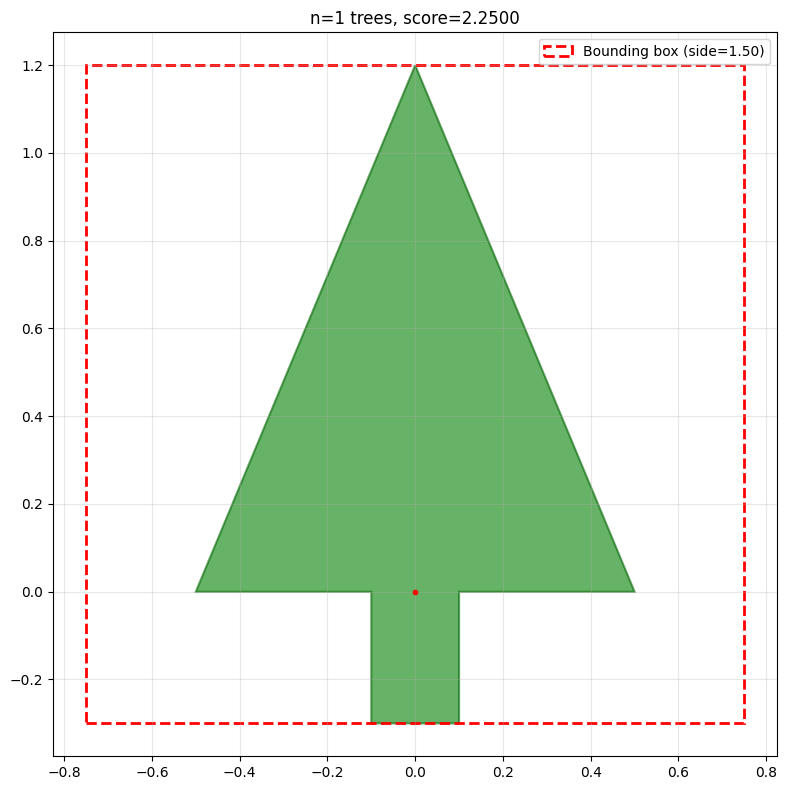

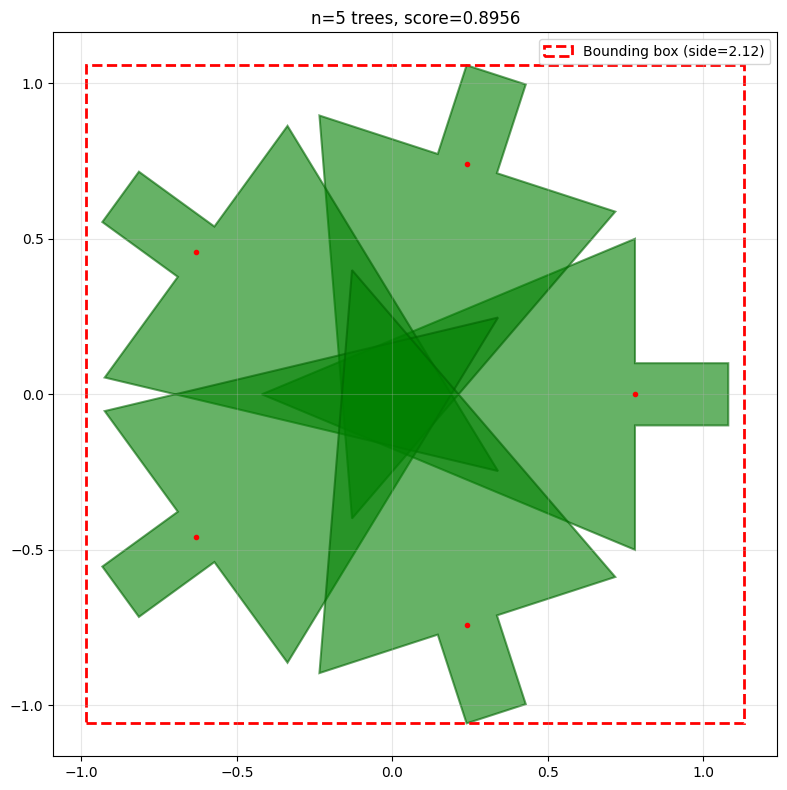

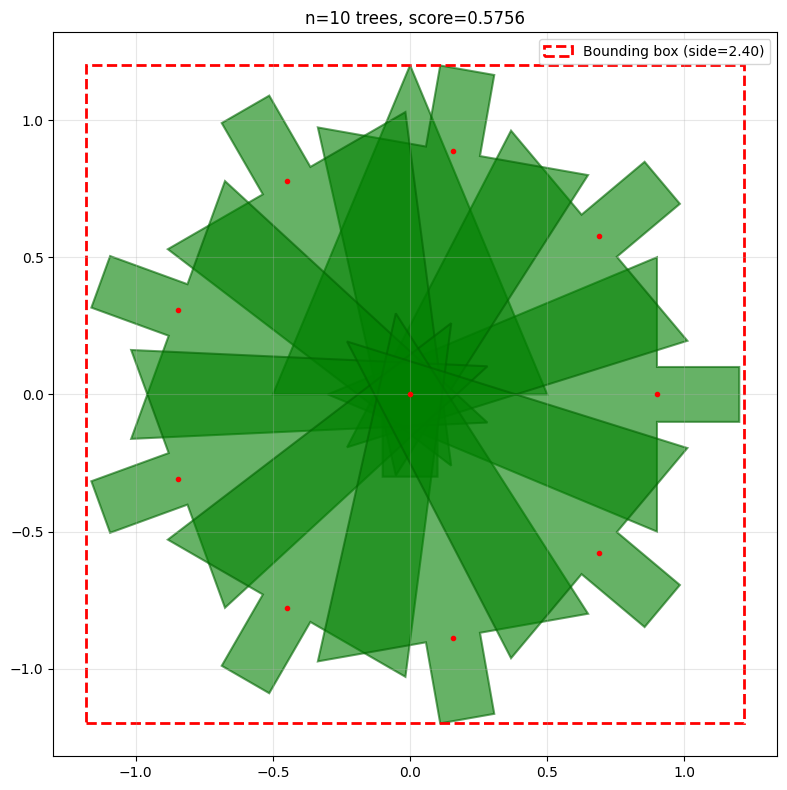

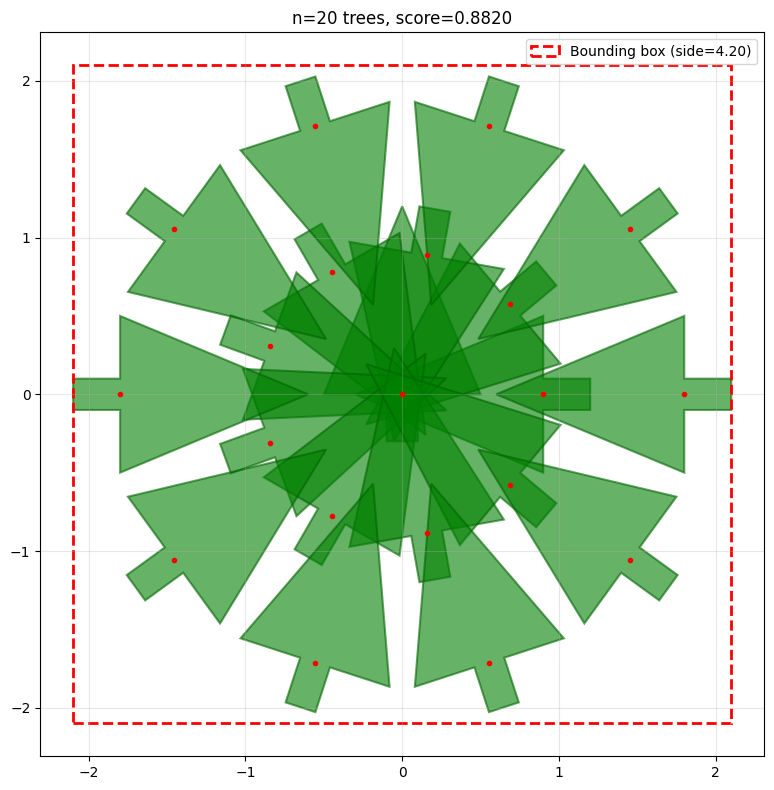

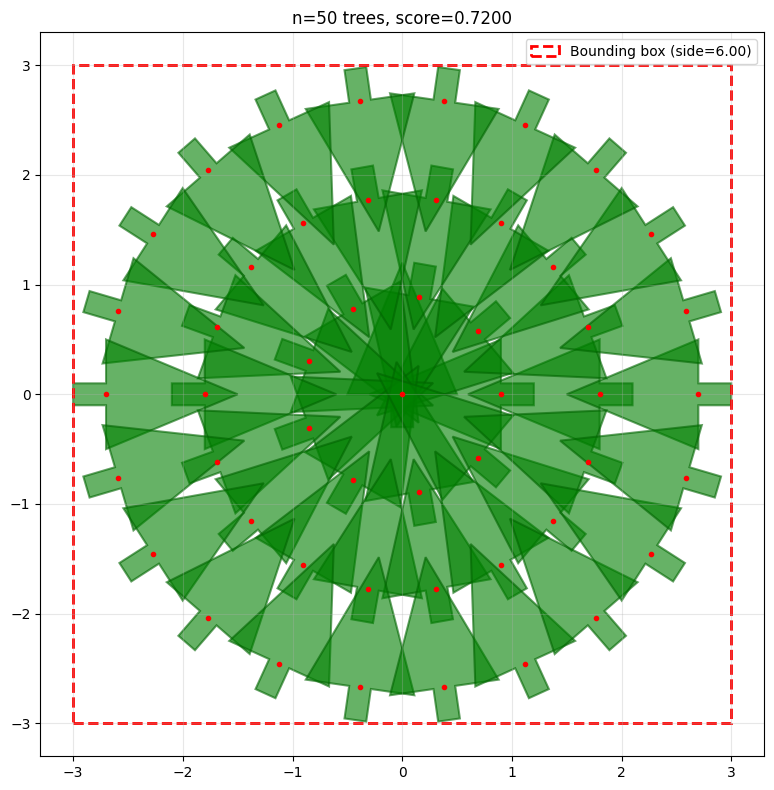

In [7]:
def visualize_packing(n, trees, title=None):
    """
    Visualize a tree packing configuration.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Draw each tree
    for i, (x, y, deg) in enumerate(trees):
        poly = transform_tree(x, y, deg)
        coords = np.array(poly.exterior.coords)
        
        patch = Polygon(coords, facecolor='green', edgecolor='darkgreen', 
                       alpha=0.6, linewidth=1.5)
        ax.add_patch(patch)
        
        # Mark reference point
        ax.plot(x, y, 'ro', markersize=3)
    
    # Draw bounding box
    side = get_bounding_box_side(trees)
    polygons = [transform_tree(x, y, deg) for x, y, deg in trees]
    all_bounds = [poly.bounds for poly in polygons]
    
    min_x = min(b[0] for b in all_bounds)
    min_y = min(b[1] for b in all_bounds)
    max_x = max(b[2] for b in all_bounds)
    max_y = max(b[3] for b in all_bounds)
    
    # Center of bounding region
    center_x = (min_x + max_x) / 2
    center_y = (min_y + max_y) / 2
    
    # Square bounding box
    box_x = center_x - side/2
    box_y = center_y - side/2
    
    from matplotlib.patches import Rectangle
    rect = Rectangle((box_x, box_y), side, side, 
                     linewidth=2, edgecolor='red', facecolor='none',
                     linestyle='--', label=f'Bounding box (side={side:.2f})')
    ax.add_patch(rect)
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    if title:
        ax.set_title(title)
    else:
        score = (side ** 2) / n
        ax.set_title(f'n={n} trees, score={score:.4f}')
    
    plt.tight_layout()
    plt.show()

# Visualize a few configurations
for n in [1, 5, 10, 20, 50]:
    visualize_packing(n, solutions[n])

## Create Submission File

Format the solution according to the competition requirements:
- Convert float values to strings with 's' prefix
- Format: id, x, y, deg

In [8]:
def create_submission(solutions, filename='submission.csv'):
    """
    Create submission file in the required format.
    """
    rows = []
    
    for n in range(1, 201):
        trees = solutions[n]
        
        for i, (x, y, deg) in enumerate(trees):
            # Format ID as nnn_i (e.g., 001_0, 023_5)
            tree_id = f"{n:03d}_{i}"
            
            # Convert values to strings with 's' prefix
            x_str = f"s{x}"
            y_str = f"s{y}"
            deg_str = f"s{deg}"
            
            rows.append({
                'id': tree_id,
                'x': x_str,
                'y': y_str,
                'deg': deg_str
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Submission saved to {filename}")
    print(f"Total rows: {len(df)}")
    return df

# Create submission
submission_df = create_submission(solutions)
submission_df.head(20)

Submission saved to submission.csv
Total rows: 20100


,id,x,y,deg
0,001_0,s0.0,s0.0,s0.0
1,002_0,s0.78,s-4.7761225166746774e-17,s90.0
2,002_1,s-0.78,s4.7761225166746774e-17,s270.0
3,003_0,s0.78,s-7.401486830834377e-17,s90.0
4,003_1,s-0.3899999999999998,s0.6754998149518621,s210.0
5,003_2,s-0.3900000000000003,s-0.6754998149518621,s330.0
6,004_0,s0.78,s-2.7755575615628914e-17,s90.0
7,004_1,s8.358214404180685e-17,s0.78,s180.0
8,004_2,s-0.78,s6.776687471786463e-17,s270.0
9,004_3,s-1.0746275662518025e-16,s-0.78,s360.0
